<>:89: SyntaxWarning: invalid escape sequence '\d'
<>:89: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_304833/2485406268.py:89: SyntaxWarning: invalid escape sequence '\d'
  """Choose jump channel from weights <psi|L^\dagger L|psi>."""


Jump-by-jump trajectory
------------------------------------------------------------
  1: t = 0.656365   channel = loss1   Pee=0.000, PS=0.025, PA=0.025, Pgg=0.950
  2: t = 1.338313   channel = loss1   Pee=0.000, PS=0.075, PA=0.075, Pgg=0.850
  3: t = 3.742742   channel =   det   Pee=0.000, PS=0.255, PA=0.000, Pgg=0.745
  4: t = 5.953846   channel = loss1   Pee=0.000, PS=0.231, PA=0.231, Pgg=0.538
  5: t = 6.031958   channel = loss2   Pee=0.000, PS=0.000, PA=0.000, Pgg=0.999
  6: t = 8.636195   channel = loss2   Pee=0.000, PS=0.181, PA=0.181, Pgg=0.638
  7: t = 9.006091   channel = loss1   Pee=0.000, PS=0.009, PA=0.009, Pgg=0.982
  8: t = 10.751190   channel = loss2   Pee=0.000, PS=0.107, PA=0.107, Pgg=0.785
  9: t = 11.700031   channel = loss1   Pee=0.000, PS=0.045, PA=0.045, Pgg=0.910
 10: t = 14.943159   channel = loss2   Pee=0.000, PS=0.223, PA=0.223, Pgg=0.553
 11: t = 18.118804   channel = loss1   Pee=0.000, PS=0.218, PA=0.218, Pgg=0.563
 12: t = 18.888006   channel = loss2   Pee

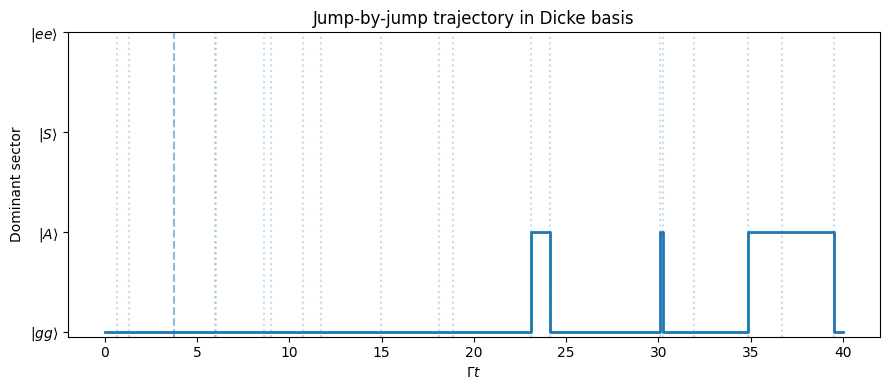

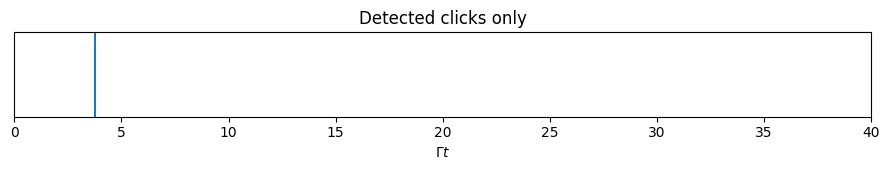

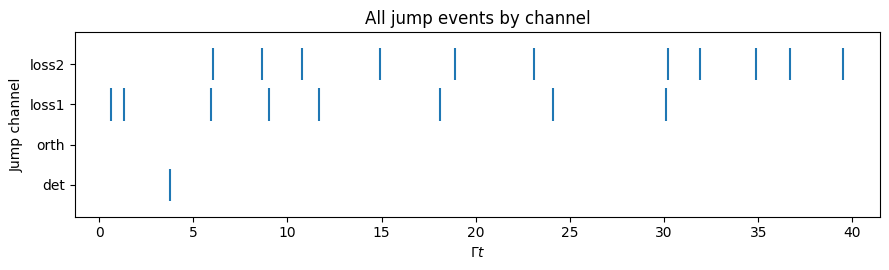

In [1]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

# ============================================================
# Two-atom Hilbert space
# ============================================================
sm = qt.sigmam()
sx = qt.sigmax()
I = qt.qeye(2)

sm1 = qt.tensor(sm, I)
sm2 = qt.tensor(I, sm)
sx1 = qt.tensor(sx, I)
sx2 = qt.tensor(I, sx)

e = qt.basis(2, 0)   # excited
g = qt.basis(2, 1)   # ground

ee = qt.tensor(e, e)
eg = qt.tensor(e, g)
ge = qt.tensor(g, e)
gg = qt.tensor(g, g)

S = (eg + ge).unit()
A = (eg - ge).unit()

# Projectors
Pee = ee * ee.dag()
PS  = S  * S.dag()
PA  = A  * A.dag()
Pgg = gg * gg.dag()

# ============================================================
# Parameters
# ============================================================
Gamma = 1.0
Omega = 0.8
eta   = 0.2
phi   = 0.0          # try 0, np.pi/2, np.pi
Omega12 = 0.0        # coherent exchange
T_max = 40.0 / Gamma

rng = np.random.default_rng(1234)

# ============================================================
# Hamiltonian and collapse operators
# ============================================================
H_drive = 0.5 * Omega * (sx1 + sx2)
H_dd    = Omega12 * (sm1.dag() * sm2 + sm2.dag() * sm1)
H = H_drive + H_dd

J_det  = np.sqrt(eta * Gamma / 2.0) * (sm1 + np.exp(1j * phi) * sm2)
J_orth = np.sqrt(eta * Gamma / 2.0) * (sm1 - np.exp(1j * phi) * sm2)
J1_loss = np.sqrt((1.0 - eta) * Gamma) * sm1
J2_loss = np.sqrt((1.0 - eta) * Gamma) * sm2

c_ops = [J_det, J_orth, J1_loss, J2_loss]
channel_names = ["det", "orth", "loss1", "loss2"]

# Effective non-Hermitian Hamiltonian
Heff = H - 0.5j * sum(c.dag() * c for c in c_ops)

# ============================================================
# Helper functions
# ============================================================
def normalize_state(psi):
    nrm = psi.norm()
    if nrm < 1e-14:
        raise RuntimeError("State norm vanished.")
    return psi / nrm

def populations(psi):
    """Return Dicke-basis populations."""
    return {
        "ee": np.real(qt.expect(Pee, psi)),
        "S":  np.real(qt.expect(PS, psi)),
        "A":  np.real(qt.expect(PA, psi)),
        "gg": np.real(qt.expect(Pgg, psi)),
    }

def dominant_sector(popdict):
    vals = [popdict["gg"], popdict["A"], popdict["S"], popdict["ee"]]
    idx = int(np.argmax(vals))
    labels = ["gg", "A", "S", "ee"]
    return idx, labels[idx]

def choose_jump_channel(psi, c_ops, rng):
    """Choose jump channel from weights <psi|L^\dagger L|psi>."""
    weights = np.array([np.real(qt.expect(c.dag() * c, psi)) for c in c_ops], dtype=float)
    total = weights.sum()
    if total <= 0:
        return None, weights
    probs = weights / total
    k = rng.choice(len(c_ops), p=probs)
    return k, weights

def evolve_until_jump(psi0, t0, T_max, Heff, c_ops, rng,
                      dt_initial=0.02, dt_min=1e-6, max_refine=30):
    """
    Event-driven evolution:
    - choose random threshold r in (0,1)
    - propagate under exp(-i Heff dt) until norm^2 crosses r
    - refine jump time by bisection-like halving
    Returns:
        jumped (bool),
        t_jump_or_end,
        psi_before_jump_normalized,
        psi_after_nojump_if_no_event,
        threshold_r
    """
    r = rng.random()
    t = t0
    psi = psi0
    dt = dt_initial

    # Advance until crossing threshold or hitting T_max
    while t < T_max:
        if t + dt > T_max:
            dt = T_max - t

        U = (-1j * Heff * dt).expm()
        psi_trial = U * psi
        norm2_trial = psi_trial.norm() ** 2

        if norm2_trial > r:
            psi = psi_trial
            t += dt
            # adapt mildly for speed
            dt = min(dt * 1.2, 0.1)
        else:
            # refine the crossing in [t, t+dt]
            left_t = t
            left_psi = psi
            left_norm2 = psi.norm() ** 2  # should be ~1 if psi normalized

            right_t = t + dt
            right_psi = psi_trial
            right_norm2 = norm2_trial

            for _ in range(max_refine):
                mid_dt = 0.5 * (right_t - left_t)
                if mid_dt < dt_min:
                    break
                U_mid = (-1j * Heff * mid_dt).expm()
                mid_psi = U_mid * left_psi
                mid_norm2 = mid_psi.norm() ** 2

                if mid_norm2 > r:
                    left_t = left_t + mid_dt
                    left_psi = mid_psi
                    left_norm2 = mid_norm2
                else:
                    right_t = left_t + mid_dt
                    right_psi = mid_psi
                    right_norm2 = mid_norm2

            # Use right endpoint as the jump time approximation
            psi_before_jump = normalize_state(right_psi)
            return True, right_t, psi_before_jump, None, r

    # No jump before T_max
    return False, T_max, normalize_state(psi), normalize_state(psi), r

# ============================================================
# Jump-by-jump trajectory
# ============================================================
psi = gg
t = 0.0

# Records
segment_times = [t]              # times where staircase changes
segment_labels = []              # dominant sector label on each interval
segment_indices = []             # 0:gg,1:A,2:S,3:ee
jump_times = []
jump_channels = []
post_jump_pops = []

# initial dominant sector
p0 = populations(psi)
idx0, lab0 = dominant_sector(p0)
segment_labels.append(lab0)
segment_indices.append(idx0)

# Main loop
while t < T_max:
    jumped, t_next, psi_before_jump, psi_nojump, r = evolve_until_jump(
        psi, t, T_max, Heff, c_ops, rng
    )

    if not jumped:
        # final interval extends to T_max
        segment_times.append(T_max)
        break

    # choose jump channel using pre-jump normalized state
    k, weights = choose_jump_channel(psi_before_jump, c_ops, rng)
    if k is None:
        segment_times.append(t_next)
        break

    # apply jump
    psi_after_jump = c_ops[k] * psi_before_jump
    psi_after_jump = normalize_state(psi_after_jump)

    # record jump
    jump_times.append(t_next)
    jump_channels.append(k)
    post_jump_pops.append(populations(psi_after_jump))

    # close old interval at jump time
    segment_times.append(t_next)

    # new interval starts just after jump with post-jump state
    idx, lab = dominant_sector(populations(psi_after_jump))
    segment_labels.append(lab)
    segment_indices.append(idx)

    # update state/time
    psi = psi_after_jump
    t = t_next

# Ensure lengths are consistent for staircase plotting
# segment_indices has one value per interval
# segment_times should have one more entry than segment_indices
if len(segment_times) == len(segment_indices):
    segment_times.append(T_max)

# ============================================================
# Print jump record
# ============================================================
print("Jump-by-jump trajectory")
print("-" * 60)
for n, (tj, ch) in enumerate(zip(jump_times, jump_channels), start=1):
    pops = post_jump_pops[n - 1]
    print(
        f"{n:3d}: t = {tj:.6f}   channel = {channel_names[ch]:>5s}   "
        f"Pee={pops['ee']:.3f}, PS={pops['S']:.3f}, PA={pops['A']:.3f}, Pgg={pops['gg']:.3f}"
    )

# detected clicks only
det_times = [tj for tj, ch in zip(jump_times, jump_channels) if ch == 0]

# ============================================================
# Plot 1: staircase of dominant Dicke sector
# ============================================================
plt.figure(figsize=(9, 4))
plt.step(np.array(segment_times) * Gamma,
         np.r_[segment_indices, segment_indices[-1]],
         where="post",
         linewidth=2)

for tj, ch in zip(jump_times, jump_channels):
    if ch == 0:
        plt.axvline(tj * Gamma, linestyle="--", alpha=0.5)
    else:
        plt.axvline(tj * Gamma, linestyle=":", alpha=0.25)

plt.yticks([0, 1, 2, 3],
           [r"$|gg\rangle$", r"$|A\rangle$", r"$|S\rangle$", r"$|ee\rangle$"])
plt.xlabel(r"$\Gamma t$")
plt.ylabel("Dominant sector")
plt.title("Jump-by-jump trajectory in Dicke basis")
plt.tight_layout()
plt.show()

# ============================================================
# Plot 2: detected clicks only
# ============================================================
plt.figure(figsize=(9, 1.8))
for tj in det_times:
    plt.vlines(tj * Gamma, 0, 1, linewidth=1.5)
plt.xlim(0, T_max * Gamma)
plt.ylim(0, 1)
plt.yticks([])
plt.xlabel(r"$\Gamma t$")
plt.title("Detected clicks only")
plt.tight_layout()
plt.show()

# ============================================================
# Plot 3: all jumps, color by channel using marker height
# ============================================================
plt.figure(figsize=(9, 2.8))
for tj, ch in zip(jump_times, jump_channels):
    plt.vlines(tj * Gamma, ch - 0.4, ch + 0.4, linewidth=1.5)

plt.yticks(range(len(channel_names)), channel_names)
plt.ylim(-0.8, len(channel_names)-0.2)
plt.xlabel(r"$\Gamma t$")
plt.ylabel("Jump channel")
plt.title("All jump events by channel")
plt.tight_layout()
plt.show()